Importing all the required libraries

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sqlalchemy import create_engine
import psycopg2
import plotly.express as px

Let's get our data from the OLAP stored in Postgres

In [13]:
db_user = "postgres"      
db_pass = "Whatsnew2711"  
db_host = "localhost"
db_port = "5432"
db_name = "coffee_sales_data"

# Create engine
engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}")

# ✅ Pass engine directly (no engine.connect())
query = "SELECT * FROM coffee_sales_data_data_science_view;"
df = pd.read_sql(query, engine)

Let's see the first 5 rows in our data

In [10]:
print(df.head())

  transaction_id  transaction_qty  total_amount transaction_date  day  month  \
0     1_20250101                2          90.0       2025-01-01    1      1   
1    10_20250101                2         105.0       2025-01-01    1      1   
2   100_20250101                2         142.5       2025-01-01    1      1   
3   101_20250101                1          45.0       2025-01-01    1      1   
4   102_20250101                2          75.0       2025-01-01    1      1   

   year    weekday transaction_time  hour  minute  second    product_category  \
0  2025  Wednesday         07:06:11     7       6      11              Coffee   
1  2025  Wednesday         07:39:34     7      39      34  Drinking Chocolate   
2  2025  Wednesday         10:49:51    10      49      51  Drinking Chocolate   
3  2025  Wednesday         10:51:17    10      51      17                 Tea   
4  2025  Wednesday         10:52:44    10      52      44              Coffee   

            product_type        

Let's check if we have any missing values in our data

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149080 entries, 0 to 149079
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149080 non-null  object 
 1   transaction_qty   149080 non-null  int64  
 2   total_amount      149080 non-null  float64
 3   transaction_date  149080 non-null  object 
 4   day               149080 non-null  int64  
 5   month             149080 non-null  int64  
 6   year              149080 non-null  int64  
 7   weekday           149080 non-null  object 
 8   transaction_time  149080 non-null  object 
 9   hour              149080 non-null  int64  
 10  minute            149080 non-null  int64  
 11  second            149080 non-null  int64  
 12  product_category  149080 non-null  object 
 13  product_type      149080 non-null  object 
 14  product_detail    149080 non-null  object 
 15  unit_price        149080 non-null  float64
 16  store_location    14

We do not have any missing data this time but if we had, this is how we would handle it:
1. For continous attributes (e.g. total amount), we would replace values with the mean
2. For categorical attributes (e.g. product_category), we would replace missing values with the most frequent value

Let's do some EDA on our data.

We'll first get some summary statistics for transaction_qty, total_amount and unit_price

In [48]:
df2 = df[['transaction_qty', 'total_amount', 'unit_price']]
df2.describe()

,transaction_qty,total_amount,unit_price
count,149080.000000,149080.000000,149080.000000
mean,1.438261,70.295068,50.901404
std,0.542518,63.411565,40.678437
min,1.000000,12.000000,12.000000
25%,1.000000,45.000000,37.500000
50%,1.000000,56.250000,45.000000
75%,2.000000,90.000000,56.250000
max,8.000000,5400.000000,675.000000


The distribution of the data is presented below

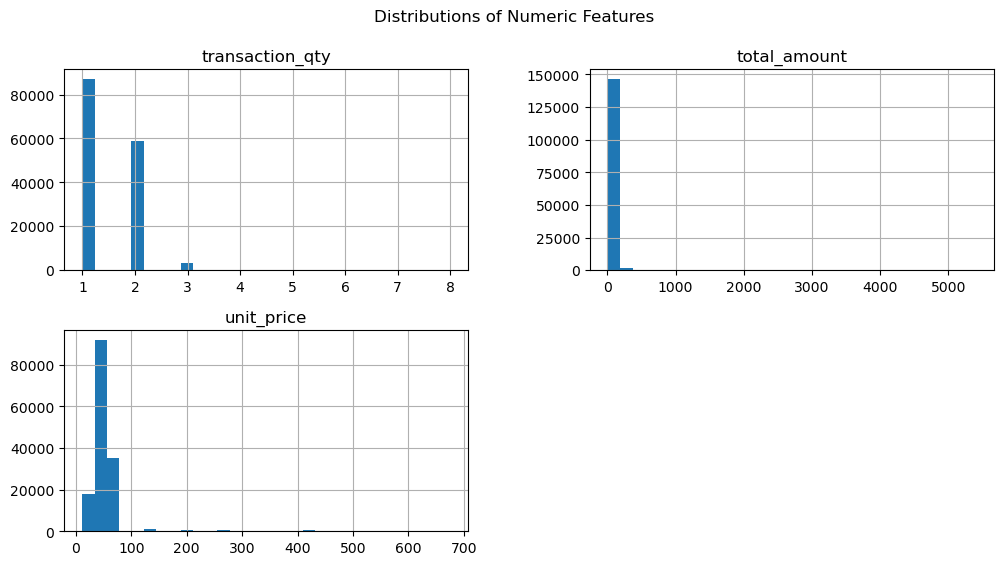

In [51]:
num_cols = ["transaction_qty", "total_amount", "unit_price"]
df[num_cols].hist(bins=30, figsize=(12,6))
plt.suptitle("Distributions of Numeric Features")
plt.show()

Let's see our daily sales trends

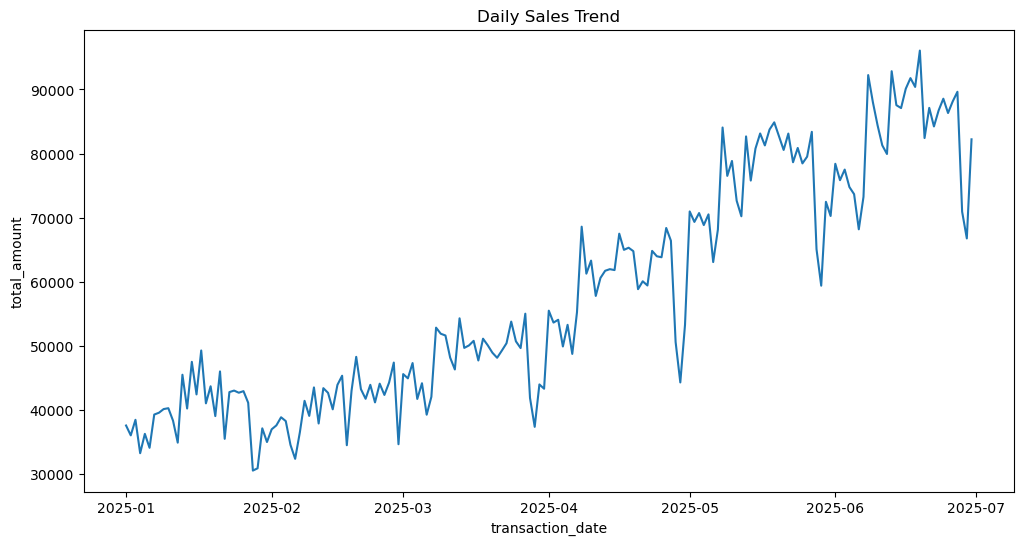

In [54]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
daily_sales = df.groupby("transaction_date")["total_amount"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_sales, x="transaction_date", y="total_amount")
plt.title("Daily Sales Trend")
plt.show()

Below we'll checkout some more sales trends, this time we'll check out weekly and hourly sales trends.

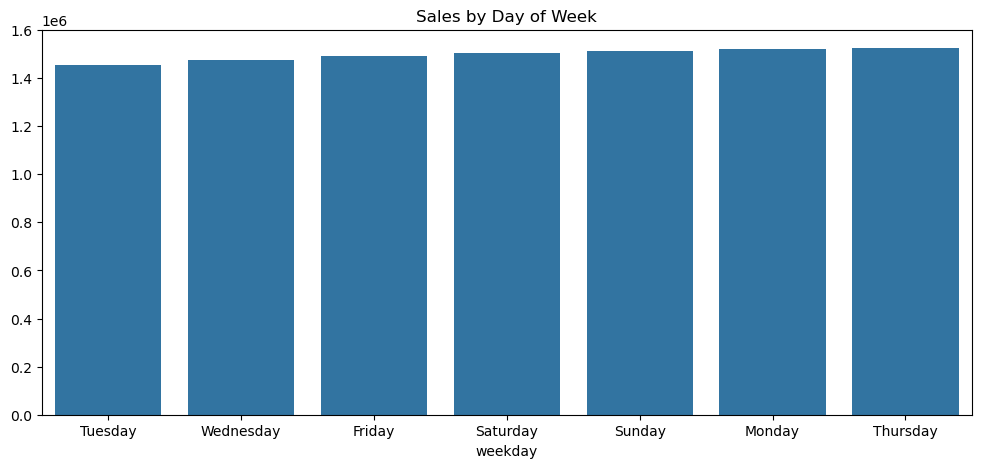

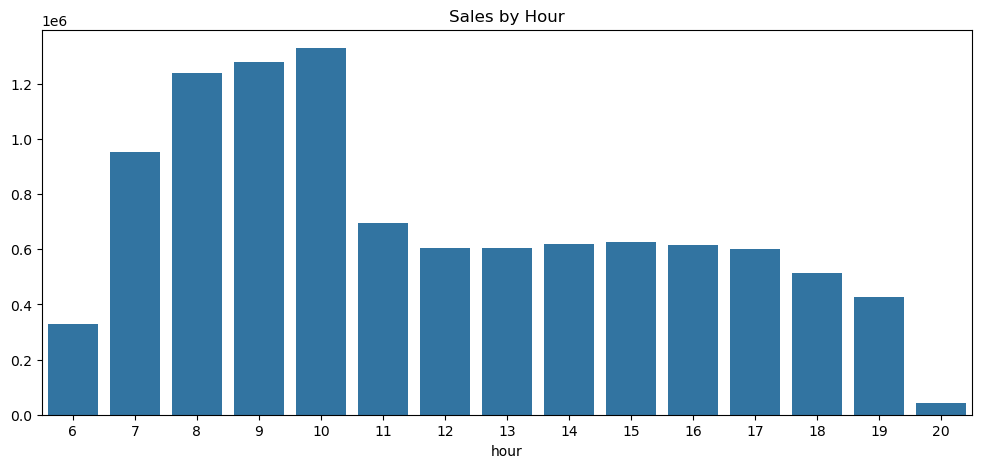

In [57]:
weekday_sales = df.groupby("weekday")["total_amount"].sum().sort_values()
hour_sales = df.groupby("hour")["total_amount"].sum()

plt.figure(figsize=(12,5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.title("Sales by Day of Week")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=hour_sales.index, y=hour_sales.values)
plt.title("Sales by Hour")
plt.show()

Let's checkout the best performing products.

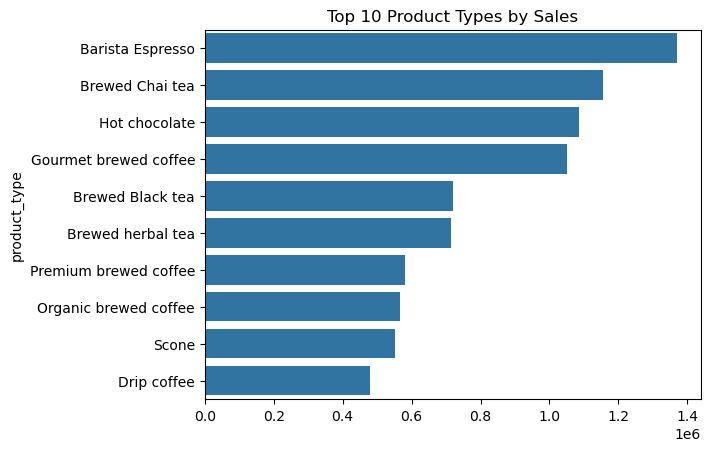

In [60]:
top_products = df.groupby("product_type")["total_amount"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Product Types by Sales")
plt.show()

Let's checkout which store is the best performer.

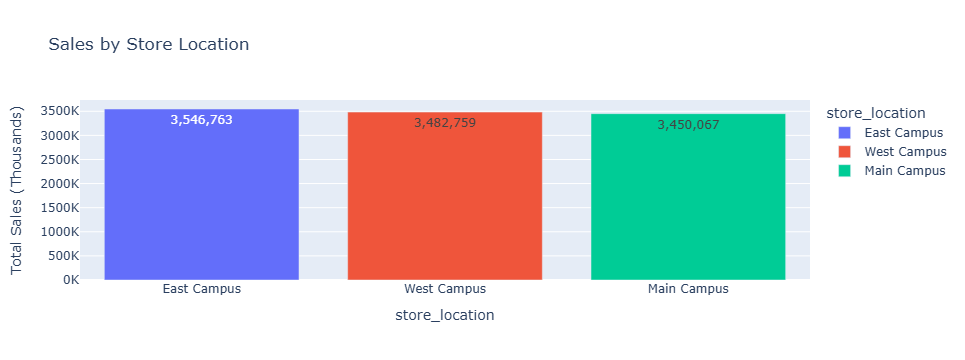

In [74]:
store_sales = (
    df.groupby("store_location")["total_amount"]
    .sum()
    .reset_index()
    .sort_values(by="total_amount", ascending=False)
)

fig = px.bar(
    store_sales,
    x="store_location",
    y="total_amount",
    title="Sales by Store Location",
    text_auto=True,
    color="store_location"
)

# Format y-axis in thousands
fig.update_layout(
    yaxis_title="Total Sales (Thousands)",
    yaxis=dict(tickformat=",d", tickprefix="")  # keep commas
)

# Divide labels shown on axis by 1000
fig.update_yaxes(tickvals=[v for v in range(0, int(store_sales["total_amount"].max()), 500000)],
                 ticktext=[f"{int(v/1000)}K" for v in range(0, int(store_sales["total_amount"].max()), 500000)])

fig.show()

Let's checkout some correlations within our data

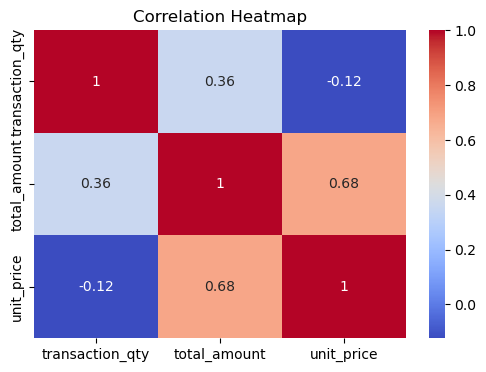

In [77]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Let's see if we have any outliers.

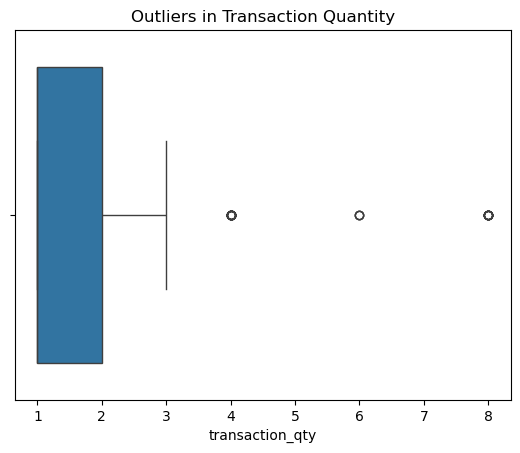

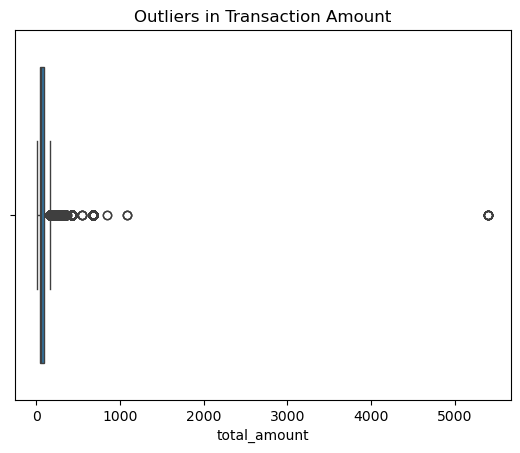

In [80]:
sns.boxplot(data=df, x="transaction_qty")
plt.title("Outliers in Transaction Quantity")
plt.show()

sns.boxplot(data=df, x="total_amount")
plt.title("Outliers in Transaction Amount")
plt.show()

Let's see which our performs the most on different days of the week

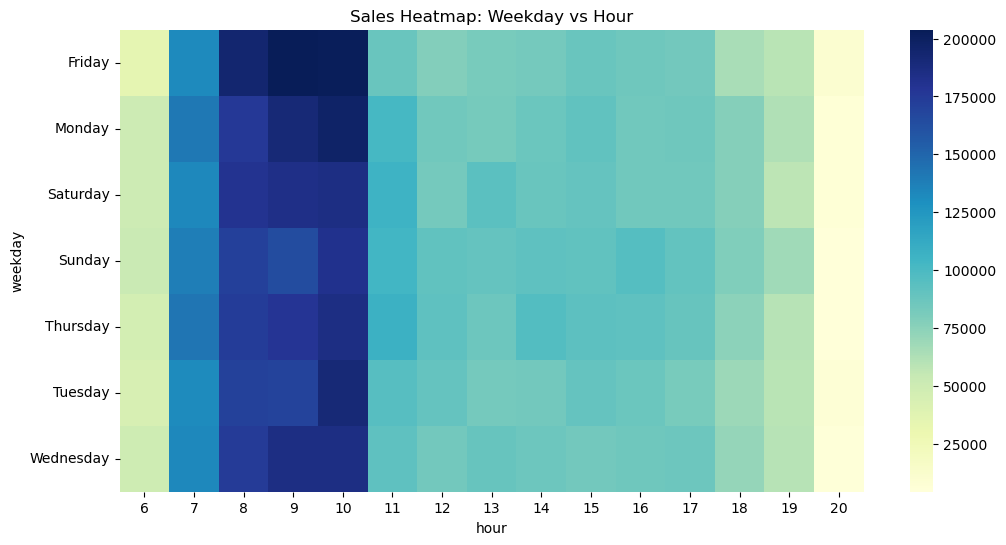

In [83]:
pivot = df.pivot_table(index="weekday", columns="hour", values="total_amount", aggfunc="sum")
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Sales Heatmap: Weekday vs Hour")
plt.show()